# IPSA (CC01-1940): EDA y preprocesamiento para clasificación

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanestebancg2806/sugarcane-yield-quality-prediction/blob/main/01_eda_ipsa.ipynb)

Este notebook prepara los datos de la **parte de clasificación** del taller. Usa `BD_IPSA_1940.xlsx`, un
subconjunto del Ingenio Providencia que el propio Ingenio construyó con estas restricciones:

- **Variedad:** CC01-1940
- **Maduración:** química (madurante BONUS 250 EC)
- **Cosecha:** mecanizada en verde

Cada fila corresponde a una cosecha de una suerte (hacienda `FAZ` + suerte `TAL` en un `periodo`).
Las conclusiones aplican solo a suertes con estas características y **no describen al Ingenio completo**.
Este análisis es independiente del de regresión sobre el histórico de suertes
(`01_eda_suertes.ipynb` / `02_modelos_regresion.ipynb`).

**Objetivo:** predecir, antes de la cosecha, el nivel (bajo / medio / alto) de dos targets:

- **TCH:** toneladas de caña por hectárea (cantidad)
- **Sacarosa:** % de sacarosa en caña (calidad)

**Flujo del notebook**

0. Alcance del dataset
1. Diccionario de datos
2. Chequeo de fuga de información
3. Auditoría de nulos y valores inválidos
4. Análisis de los dos targets
5. Relación predictor → target
6. VIF
7. Selección final de predictores
8. Definición de las clases (terciles vs. umbrales de negocio)
9. Exportación y limitaciones

**Siguiente paso:** los modelos (logística multinomial regularizada y KNN) están en
`02_modelos_clasificacion.ipynb`.

> **Datos:** `BD_IPSA_1940.xlsx` no está en el repositorio porque el enunciado prohíbe publicar los datos.
> En Colab hay que subirlo manualmente al directorio de trabajo antes de ejecutar.

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats



pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

%matplotlib inline

## Carga de datos

Se lee la hoja `BD_IPSA` del archivo `BD_IPSA_1940.xlsx`, se elimina el índice residual que trae el
Excel y se revisa una vista general: primeras filas, tipos de dato, conteo de nulos y estadísticos
descriptivos.

In [49]:
# Lectura del dataset IPSA
df_ipsa = pd.read_excel("BD_IPSA_1940.xlsx", sheet_name="BD_IPSA")

# La primera columna de IPSA es un índice residual del Excel
if "Unnamed: 0" in df_ipsa.columns:
    df_ipsa = df_ipsa.drop(columns=["Unnamed: 0"])

print("BD_IPSA:", df_ipsa.shape)


BD_IPSA: (2187, 20)


In [50]:
# Vista rápida: IPSA (variedad CC01-1940)
display(df_ipsa.head())
df_ipsa.info()
display(df_ipsa.describe(include="all").T)

,NOME,FAZ,TAL,tipocorte,variedad,madurada,producto,dosismad,semsmad,edad,cortes,me,vejez,sacarosa,mes,periodo,TCH,lluvias,grupo_tenencia,pct_diatrea
0,AMAIME SILCA,81291,40,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,8.3,12.3,4,12.7,2.4,14.0,12,202012,112,137,3,6.2
1,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.3,11.2,2,7.8,2.3,13.0,3,201903,157,0,3,3.5
2,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,7.9,12.2,3,8.8,1.8,13.3,3,202003,167,68,3,4.3
3,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.6,13.1,1,6.1,2.5,13.4,3,201903,156,0,3,3.5
4,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,8.1,12.2,2,7.9,2.1,14.0,3,202003,151,68,3,4.3


<class 'pandas.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NOME            2187 non-null   str    
 1   FAZ             2187 non-null   int64  
 2   TAL             2187 non-null   object 
 3   tipocorte       2187 non-null   str    
 4   variedad        2187 non-null   str    
 5   madurada        2187 non-null   str    
 6   producto        2187 non-null   str    
 7   dosismad        2187 non-null   float64
 8   semsmad         2187 non-null   float64
 9   edad            2187 non-null   float64
 10  cortes          2187 non-null   int64  
 11  me              2187 non-null   float64
 12  vejez           2187 non-null   float64
 13  sacarosa        2187 non-null   float64
 14  mes             2187 non-null   int64  
 15  periodo         2187 non-null   int64  
 16  TCH             2187 non-null   int64  
 17  lluvias         2187 non-null   int64  
 18 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
NOME,2187,285,SAN MIGUEL CARVAJAL,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FAZ,2187.0,NaN,NaN,NaN,80588.332876,572.818299,80100.0,80222.0,80396.0,80660.0,82519.0
TAL,2187.0,273.0,1.0,258.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipocorte,2187,1,Mecanizado Verde,2187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
variedad,2187,1,CC01-1940,2187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
madurada,2187,1,SI,2187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
producto,2187,1,BONUS 250 EC REGULADOR FISIOLÓGICO,2187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dosismad,2187.0,NaN,NaN,NaN,0.993278,0.309096,0.0,0.8,1.0,1.2,9.0
semsmad,2187.0,NaN,NaN,NaN,9.164838,3.441579,-1.6,7.1,8.7,10.6,45.0
edad,2187.0,NaN,NaN,NaN,12.766118,1.117866,10.3,12.0,12.5,13.3,21.1


## 0. Alcance del dataset

`BD_IPSA_1940` es un recorte del Ingenio Providencia, no una muestra aleatoria. Si una condición de
manejo (variedad, maduración o tipo de cosecha) es igual en todas las filas, su efecto no se puede
estimar y las conclusiones solo aplican a suertes que compartan esa condición.

En esta sección se verifica si `variedad`, `madurada`, `producto` y `tipocorte` tienen un único valor
en todo el dataset.

In [51]:
# 0. Verificar que las columnas de alcance son constantes
cols_alcance = ["variedad", "madurada", "producto", "tipocorte"]

resumen_alcance = pd.DataFrame({
    "n_valores_unicos": df_ipsa[cols_alcance].nunique(),
    "valor": [df_ipsa[c].iloc[0] for c in cols_alcance],
})
display(resumen_alcance)

# Detener la ejecución si alguna columna de alcance no es constante
assert (resumen_alcance["n_valores_unicos"] == 1).all(), "Alguna columna de alcance NO es constante"

,n_valores_unicos,valor
variedad,1,CC01-1940
madurada,1,SI
producto,1,BONUS 250 EC REGULADOR FISIOLÓGICO
tipocorte,1,Mecanizado Verde


### Conclusión de la sección 0

Las cuatro columnas tienen un único valor en las 2.187 filas:

| Columna | Valor único | Qué no se puede estudiar con este dataset |
|---|---|---|
| `variedad` | CC01-1940 | Diferencias entre variedades |
| `madurada` | SI | Suertes maduradas vs. no maduradas |
| `producto` | BONUS 250 EC | Diferencias entre madurantes |
| `tipocorte` | Mecanizado Verde | Cosecha mecanizada vs. manual o con quema |

- Las cuatro columnas se excluyen como predictores porque, al ser constantes, no aportan información.
- Los resultados de los modelos aplican solo a suertes de CC01-1940 maduradas químicamente y
  cosechadas en verde con máquina.

## 1. Diccionario de datos

El diccionario oficial de `BD_IPSA` describe cada columna de forma breve y, en algunos casos, genérica.
Antes de usar una columna como predictor hay que confirmar qué mide y en qué unidad, porque una
interpretación equivocada puede invalidar el análisis posterior.

En esta sección se compara la descripción oficial de cada columna con su comportamiento real en los
datos (tipo, número de valores distintos y rango). Las columnas cuya descripción falte, sea ambigua o
no sea coherente con los valores observados se investigan por separado.

In [52]:
# Descripciones del diccionario oficial de BD_IPSA ("" = sin descripción)
dicc_oficial = {
    "NOME": "Nombre del registro (finca, campo o unidad de análisis)",
    "FAZ": "Código o identificador de la hacienda o finca",
    "TAL": "Identificador de una subunidad o lote",
    "tipocorte": "Tipo de corte realizado",
    "variedad": "Variedad del cultivo",
    "madurada": "Indicador relacionado con la maduración del cultivo",
    "producto": "",
    "dosismad": "Dosis aplicada de fertilizantes o agroquímicos",
    "semsmad": "Dosis aplicada de fertilizantes o agroquímicos",
    "edad": "Edad del cultivo al momento del registro (días, semanas o meses)",
    "cortes": "Número de cortes o cosechas realizadas en el periodo",
    "me": "",
    "vejez": "Edad o antigüedad del cultivo",
    "sacarosa": "Porcentaje o cantidad de sacarosa",
    "mes": "Mes del registro o de la cosecha",
    "periodo": "Periodo o año del registro",
    "TCH": "Toneladas de caña por hectárea",
    "lluvias": "Lluvias registradas en el periodo (mm)",
    "grupo_tenencia": "Categoría de tenencia del terreno",
    "pct_diatrea": "Porcentaje de infestación por diatrea",
}

filas = []
for col in df_ipsa.columns:
    s = df_ipsa[col]
    es_num = pd.api.types.is_numeric_dtype(s)
    filas.append({
        "columna": col,
        "descripcion_oficial": dicc_oficial.get(col, ""),
        "tipo": str(s.dtype),
        "n_unicos": s.nunique(),
        "min": s.min() if es_num else None,
        "mediana": s.median() if es_num else None,
        "max": s.max() if es_num else None,
        "ejemplos": list(s.drop_duplicates().head(4)),
    })

inventario = pd.DataFrame(filas).set_index("columna")
display(inventario)

,descripcion_oficial,tipo,n_unicos,min,mediana,max,ejemplos
columna,,,,,,,
NOME,"Nombre del registro (finca, campo o unidad de ...",str,285,NaN,NaN,NaN,"[AMAIME SILCA, ARANJUEZ, AURORA CUCALON, BARCE..."
FAZ,Código o identificador de la hacienda o finca,int64,285,80100.0,80396.0,82519.0,"[81291, 80552, 80601, 80492]"
TAL,Identificador de una subunidad o lote,object,273,NaN,NaN,NaN,"[40, 41, 43, 1]"
tipocorte,Tipo de corte realizado,str,1,NaN,NaN,NaN,[Mecanizado Verde]
variedad,Variedad del cultivo,str,1,NaN,NaN,NaN,[CC01-1940]
madurada,Indicador relacionado con la maduración del cu...,str,1,NaN,NaN,NaN,[SI]
producto,,str,1,NaN,NaN,NaN,[BONUS 250 EC REGULADOR FISIOLÓGICO]
dosismad,Dosis aplicada de fertilizantes o agroquímicos,float64,18,0.0,1.0,9.0,"[0.8, 0.6, 1.2, 1.0]"
semsmad,Dosis aplicada de fertilizantes o agroquímicos,float64,150,-1.6,8.7,45.0,"[8.3, 6.3, 7.9, 6.6]"


### Observaciones sobre el inventario

**Columnas cuya descripción es coherente con los valores observados:**

- `NOME` y `FAZ` tienen 285 valores distintos cada una, lo que sugiere que son el nombre y el código de
  la misma hacienda. `TAL` tiene 273 valores y es de tipo `object`, es decir, mezcla tipos de dato.
- `edad` va de 10.3 a 21.1 (mediana 12.5). La descripción oficial no fija la unidad, pero ese rango solo
  es coherente con meses: un ciclo de cultivo dura aproximadamente entre 12 y 18 meses.
- `cortes` toma valores enteros de 1 a 14.
- `sacarosa` (9.2 a 16.0 %), `TCH` (6 a 249 t/ha), `pct_diatrea` (0.2 a 25.5 %) y `lluvias` (0 a 1.468 mm)
  tienen unidades explícitas y rangos plausibles. Sus valores extremos se revisan más adelante.
- `mes` va de 1 a 12, y `periodo` tiene formato AAAAMM (201407 a 202101).

**Columnas que requieren revisión:**

| Columna | Problema |
|---|---|
| `me` | No tiene descripción en el diccionario. Rango de 3.4 a 15.0. |
| `vejez` | La descripción oficial ("antigüedad del cultivo") no es coherente con un rango de 0.2 a 102.9 con mediana 2.6, y la edad del cultivo ya está en `edad`. |
| `dosismad` | Descripción genérica y sin unidad. Máximo de 9.0 frente a una mediana de 1.0, y mínimo de 0.0 aunque todas las suertes figuran como maduradas. |
| `semsmad` | La descripción es idéntica a la de `dosismad`. Su rango (−1.6 a 45.0) no es coherente con una dosis, y un valor negativo no es coherente con ninguna cantidad física. |
| `grupo_tenencia` | Tres códigos (1, 2, 3) sin significado documentado. |

Además, antes de interpretar las columnas hay que confirmar qué representa cada fila. Con 285 haciendas
y 2.187 filas, cada hacienda aparece en varios registros.

### 1.1 Unidad de observación

Se verifica si `NOME` y `FAZ` identifican la misma hacienda, qué tipos de valores contiene `TAL` y si
sus valores de texto son códigos o números almacenados como texto, si `mes` es redundante con
`periodo`, y si la combinación hacienda + suerte + periodo identifica una fila única.

In [53]:
# 1.1 Unidad de observación

# ¿NOME y FAZ identifican la misma hacienda?
print("FAZ con más de un NOME:", (df_ipsa.groupby("FAZ")["NOME"].nunique() > 1).sum())
print("NOME con más de un FAZ:", (df_ipsa.groupby("NOME")["FAZ"].nunique() > 1).sum())

# TAL es de tipo object: ¿qué tipos de valores contiene?
display(df_ipsa["TAL"].map(lambda v: type(v).__name__).value_counts().to_frame("n_filas"))

# ¿mes coincide con los dos últimos dígitos de periodo?
print("Filas donde mes != periodo % 100:", (df_ipsa["mes"] != df_ipsa["periodo"] % 100).sum())

# TAL como texto para poder agrupar sin errores por la mezcla de tipos
tal_txt = df_ipsa["TAL"].astype(str)

# ¿hacienda + suerte + periodo identifica una fila única?
dup = df_ipsa.assign(TAL=tal_txt).duplicated(subset=["FAZ", "TAL", "periodo"], keep=False)
print("Filas con FAZ + TAL + periodo repetido:", dup.sum())

# ¿Cuántas cosechas tiene cada suerte en el dataset?
cosechas_por_suerte = df_ipsa.assign(TAL=tal_txt).groupby(["FAZ", "TAL"]).size()
print("Suertes distintas (FAZ + TAL):", len(cosechas_por_suerte))
display(cosechas_por_suerte.value_counts().sort_index().rename("n_suertes").to_frame())

FAZ con más de un NOME: 0
NOME con más de un FAZ: 0


,n_filas
TAL,
int,1598
str,589


Filas donde mes != periodo % 100: 0
Filas con FAZ + TAL + periodo repetido: 0
Suertes distintas (FAZ + TAL): 1115


,n_suertes
1,486
2,337
3,168
4,98
5,25
6,1


In [54]:
# Valores de TAL almacenados como texto: ¿son códigos alfanuméricos o números guardados como texto?
tal_str = df_ipsa.loc[df_ipsa["TAL"].map(lambda v: isinstance(v, str)), "TAL"]

es_numerico = tal_str.str.strip().str.fullmatch(r"\d+")
print("Valores de texto que son solo dígitos:", es_numerico.sum(), "de", len(tal_str))
print("Ejemplos:", tal_str.drop_duplicates().head(15).tolist())

Valores de texto que son solo dígitos: 0 de 589
Ejemplos: ['990A', '991B', '991C', '991D', '991E', '991G', '320B', '322A', '324A', '005A', '006A', '010A', '004A', '001A', '002B']


#### Conclusión de 1.1

- `NOME` y `FAZ` están en relación 1 a 1: son el nombre y el código de la misma hacienda, así que
  `NOME` es redundante con `FAZ`.
- `TAL` combina 1.598 valores enteros y 589 códigos alfanuméricos (por ejemplo, `005A` y `991B`).
  Ninguno de los valores de texto es un número almacenado como texto, por lo que la mezcla de tipos no
  duplica suertes. La letra final parece indicar una subdivisión de la suerte. Para agrupar, `TAL` se
  trata como texto.
- `mes` coincide en todas las filas con los dos últimos dígitos de `periodo`, así que su información ya
  está contenida en `periodo`.
- La combinación `FAZ` + `TAL` + `periodo` no se repite, así que **cada fila es una cosecha de una
  suerte**.
- El dataset contiene 1.115 suertes distintas. 486 aparecen en una sola cosecha y 629 en dos o más
  (hasta seis):

| Cosechas por suerte | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|
| Número de suertes | 486 | 337 | 168 | 98 | 25 | 1 |

Como una misma suerte aparece en varias filas, las observaciones no son independientes entre sí. Una
partición aleatoria de filas en entrenamiento y prueba puede dejar cosechas de la misma suerte en
ambos conjuntos, y el desempeño en prueba resultaría optimista. Esto se tiene en cuenta al construir
la partición en `02_modelos_clasificacion.ipynb`.

### 1.2 Columna `vejez`

El diccionario oficial describe `vejez` como la edad o antigüedad del cultivo. Según información
suministrada por el Ingenio, en cambio, representa las horas transcurridas entre el corte (o una quema
accidental) y la llegada de la caña al molino. En operación normal el valor es menor a 10 horas, y
valores del orden de 70 horas corresponden a quemas accidentales.

Se revisa cuál de las dos interpretaciones es coherente con la distribución observada, comparando
`vejez` con `edad`, que ya representa la edad del cultivo en meses.

In [55]:
# 1.2 Columna vejez
vejez = df_ipsa["vejez"]

display(vejez.describe(percentiles=[.25, .5, .75, .90, .95, .99]).round(2).to_frame("vejez"))

# Si vejez fuera la edad del cultivo, debería parecerse a edad (10-21 meses) y correlacionar con ella
print("Correlación de Spearman vejez-edad:", round(vejez.corr(df_ipsa["edad"], method="spearman"), 3))

# Proporción de registros por rangos de horas (según el Ingenio, < 10 h en operación normal)
rangos = pd.cut(vejez, bins=[0, 10, 24, 48, np.inf], labels=["<10 h", "10-24 h", "24-48 h", ">48 h"])
display(rangos.value_counts().sort_index().to_frame("n_filas")
        .assign(pct=lambda d: (d["n_filas"] / len(df_ipsa) * 100).round(1)))

,vejez
count,2187.00
mean,4.17
std,6.34
min,0.20
25%,2.10
50%,2.60
75%,3.30
90%,6.30
95%,14.47
99%,33.57


Correlación de Spearman vejez-edad: 0.112


,n_filas,pct
vejez,,
<10 h,2038,93.2
10-24 h,108,4.9
24-48 h,32,1.5
>48 h,9,0.4


#### Conclusión de 1.2

- La correlación de Spearman entre `vejez` y `edad` es de 0.112. Si `vejez` representara la antigüedad
  del cultivo, estaría fuertemente relacionada con `edad`, así que la descripción del diccionario
  oficial no corresponde a esta columna.
- La distribución es coherente con horas entre corte y molienda: mediana de 2.6 h, el 75 % de los
  registros por debajo de 3.3 h y el 93.2 % por debajo de 10 h, el umbral de operación normal indicado por el Ingenio.
- Hay una cola larga pequeña: 108 registros (4.9 %) entre 10 y 24 h, 32 (1.5 %) entre 24 y 48 h y
  9 (0.4 %) por encima de 48 h, con un máximo de 102.9 h. Según el Ingenio, estos valores corresponden a
  eventos operativos como quemas accidentales, no a errores de escala.
- Se adopta la definición del Ingenio: **`vejez` = horas entre el corte de la caña y su llegada al
  molino**. Al ser una medida posterior al corte, su uso como predictor se evalúa en la sección 2.

### 1.3 Columna `me`

Ninguna fuente describe esta columna. Su rango observado va de 3.4 a 15.0, con mediana 9.1.

**Hipótesis principal: materia extraña (% en peso).** Es el material que llega al molino junto con los
tallos y no es caña aprovechable: hojas, cogollos, chulquines y tierra. Hay tres argumentos a favor:

- El rango es coherente con los porcentajes que reporta Cenicaña, por ejemplo un promedio de 7.48 % en
  Riopaila [1]. En cosecha mecanizada en verde se esperan valores mayores, porque la máquina arrastra
  más hojas y cogollos.
- La materia extraña y el tiempo entre corte y molienda (`vejez`) se miden juntos al recibir la caña
  en el molino [2].
- La materia extraña no contiene sacarosa y la diluye. Cenicaña reporta una reducción de 0.13 a 0.17
  puntos de pol por cada 1 % de materia extraña [1]. Por eso se espera una relación negativa con
  `sacarosa`.

**Hipótesis alternativa: un tiempo en meses**, por ejemplo la edad del cultivo al aplicar el madurante.
Se descarta si `me` supera a `edad` en una proporción relevante de filas.

**Fuentes**

1. Cenicaña. *Calidad de la caña de azúcar*. En: El cultivo de la caña en la zona azucarera de Colombia,
   pp. 337-354. https://www.cenicana.org/pdf_privado/documentos_no_seriados/libro_el_cultivo_cana/libro_p337-354.pdf
2. Universidad Nacional Abierta y a Distancia (UNAD). *Impacto generado por la presencia de materia
   extraña y tiempo de permanencia de caña de azúcar cosechada en campo en la disminución del contenido
   de sacarosa en los ingenios del Valle del Cauca*. https://repository.unad.edu.co/handle/10596/51320

In [56]:
# 1.3 Columna me
me = df_ipsa["me"]

# Hipótesis alternativa: si me > edad en muchas filas, me no puede ser un tiempo en meses previo al corte
n_mayor = (me > df_ipsa["edad"]).sum()
print(f"Filas con me > edad: {n_mayor} de {len(df_ipsa)} ({n_mayor / len(df_ipsa):.1%})")

display(me.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2).to_frame("me"))

# Spearman: captura relaciones monótonas aunque no sean lineales
cols = ["sacarosa", "TCH", "vejez", "edad", "cortes", "lluvias", "mes"]
rho = df_ipsa[cols + ["me"]].corr(method="spearman")["me"].drop("me")
display(rho.round(3).to_frame("rho_spearman_con_me"))

# Evolución por año de cosecha
display(df_ipsa.groupby(df_ipsa["periodo"] // 100)["me"]
        .agg(["count", "median", "mean", "min", "max"]).round(2))

Filas con me > edad: 83 de 2187 (3.8%)


,me
count,2187.00
mean,9.20
std,1.57
min,3.40
1%,5.70
5%,6.80
25%,8.20
50%,9.10
75%,10.10
95%,12.00


,rho_spearman_con_me
sacarosa,-0.285
TCH,0.017
vejez,-0.044
edad,-0.129
cortes,0.166
lluvias,0.004
mes,-0.061


,count,median,mean,min,max
periodo,,,,,
2014,1,5.8,5.80,5.8,5.8
2015,35,7.7,7.88,5.4,10.3
2016,110,8.5,8.61,4.9,13.3
2017,217,9.1,9.06,4.4,13.2
2018,408,8.8,8.99,3.9,14.5
2019,602,9.1,9.31,5.0,15.0
2020,728,9.2,9.36,3.4,15.0
2021,86,9.6,9.68,6.6,12.7


#### Conclusión de 1.3

- **Hipótesis temporal descartada.** La correlación de Spearman entre `me` y `edad` es débil y negativa
  (−0.129). Si `me` fuera un tiempo en meses dentro del ciclo del cultivo, crecería con la edad. Además,
  en 83 filas (3.8 %) `me` supera a `edad`, algo imposible para un evento anterior al corte.
- **Hipótesis de materia extraña respaldada.** La relación más fuerte de `me` es con `sacarosa`
  (ρ = −0.285), negativa como se espera si la materia extraña diluye el contenido de sacarosa. Con `TCH`
  la relación es nula (ρ = 0.017).
- La distribución es compacta y coherente con un porcentaje en peso: el 90 % central de los registros
  está entre 6.8 y 12.0, con mediana 9.1.
- La mediana anual pasa de 7.7 en 2015 a 9.6 en 2021 (2014 tiene un solo registro). Esa tendencia es
  compatible con un indicador de la operación de cosecha más que con una propiedad del cultivo.
- Dos resultados no aportan evidencia a favor: la correlación con `lluvias` es prácticamente nula
  (ρ = 0.004), aunque `lluvias` tiene ceros cuya validez se revisa en la sección 3, y la correlación
  positiva con `cortes` (ρ = 0.166) no tiene una explicación establecida.
- Se adopta como hipótesis de trabajo, con confianza moderada y sin confirmación del Ingenio:
  **`me` = materia extraña (% en peso de la caña entregada)**. Bajo esta interpretación, `me` se mide al
  recibir la caña en el molino, así que su uso como predictor se evalúa en la sección 2.

### 1.4 Columna `dosismad`

El diccionario oficial describe `dosismad` de forma genérica ("dosis aplicada de fertilizantes o
agroquímicos") y no indica la unidad. Como `producto` es constante (BONUS 250 EC), la columna se
interpreta como la dosis del madurante.

BONUS 250 EC es un regulador de crecimiento cuyo ingrediente activo es el trinexapac-etil. Para uso
como madurante en caña, el fabricante recomienda 1.2 L/ha, equivalente a 7-8 cc por tonelada de caña
estimada al momento de la aplicación [1]. La mediana observada (1.0) es coherente con una dosis en L/ha.

Quedan dos aspectos por revisar:

- El valor máximo de 9.0 está muy por encima de la dosis recomendada en L/ha, pero dentro del orden
  de magnitud de la dosis expresada en cc por tonelada.
- Hay registros con dosis 0.0, aunque todas las suertes figuran como maduradas (`madurada = SI`).

**Fuentes**

1. Syngenta Colombia. *BONUS® 250 EC – Regulador de crecimiento*.
   https://www.syngenta.com.co/product/crop-protection/regulador-de-crecimiento/bonusr-250-ec

In [57]:
# 1.4 Columna dosismad
dosis = df_ipsa["dosismad"]

# Distribución completa de valores (la columna tiene pocos valores distintos)
display(dosis.value_counts().sort_index().to_frame("n_filas")
        .assign(pct=lambda d: (d["n_filas"] / len(df_ipsa) * 100).round(2)))

# Registros fuera del rango habitual: dosis 0 o por encima de 2.0 L/ha
cols_ver = ["FAZ", "TAL", "periodo", "dosismad", "semsmad", "edad", "sacarosa", "TCH"]
display(df_ipsa.loc[(dosis == 0) | (dosis > 2.0), cols_ver].sort_values("dosismad"))

,n_filas,pct
dosismad,,
0.0,1,0.05
0.2,2,0.09
0.3,4,0.18
0.5,103,4.71
0.6,56,2.56
0.7,12,0.55
0.8,757,34.61
1.0,492,22.50
1.1,57,2.61


,FAZ,TAL,periodo,dosismad,semsmad,edad,sacarosa,TCH
1204,80232,1,201603,0.0,8.1,12.9,13.3,157
1652,80179,1,201512,9.0,6.1,13.3,14.6,104


#### Conclusión de 1.4

- El 99.9 % de los registros tiene una dosis entre 0.2 y 2.0. Los valores más frecuentes son 0.8
  (34.6 %), 1.0 (22.5 %) y 1.2 (19.5 %), coherentes con la dosis recomendada por el fabricante para
  BONUS 250 EC como madurante (1.2 L/ha). Se adopta la interpretación **`dosismad` = dosis del
  madurante en L/ha**.
- Dos registros quedan fuera de ese rango:

| FAZ | TAL | periodo | dosismad | semsmad |
|---|---|---|---|---|
| 80232 | 1 | 201603 | 0.0 | 8.1 |
| 80179 | 1 | 201512 | 9.0 | 6.1 |

- En ambos casos `semsmad` tiene un valor dentro del rango habitual, lo que indica que el madurante sí
  se aplicó. En el histórico de suertes del Ingenio, un cero o vacío en la dosis de madurante
  significa que no se aplicó madurante. Esa regla no aplica aquí: en este dataset todas las suertes
  figuran como maduradas (`madurada = SI`) con el mismo producto, y la fila con dosis 0.0 tiene semanas
  de maduración registradas. La dosis 0.0 se interpreta como un dato no registrado. La dosis 9.0 es
  compatible tanto con un error de digitación (0.9) como con un registro en cc por tonelada de caña
  (7-8 cc/t según el fabricante), sin forma de distinguir entre ambas con los datos disponibles.
- Los dos registros representan el 0.09 % del dataset. Su tratamiento se define en la sección 3.

### 1.5 Columna `semsmad`

La descripción de `semsmad` en el diccionario oficial es idéntica a la de `dosismad`, por lo que no
aporta información. Por el nombre (semanas + madurante) y por la mediana de 8.7, la hipótesis de
trabajo es que representa las **semanas transcurridas entre la aplicación del madurante y la cosecha**.

Bajo esta hipótesis hay dos valores incoherentes: el mínimo de −1.6, porque el madurante no puede
aplicarse después de la cosecha, y el máximo de 45.0, porque equivale a unos 10 meses. Con una edad
mediana de cosecha de 12.5 meses, eso implicaría aplicar el madurante cuando el cultivo tenía unos
dos meses.

Se revisa la distribución, la cantidad de valores negativos o extremos, y la coherencia con `edad`:
las semanas de maduración, convertidas a meses, no pueden superar la edad del cultivo.

In [58]:
# 1.5 Columna semsmad
sem = df_ipsa["semsmad"]

display(sem.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2).to_frame("semsmad"))

# Rangos de semanas para ubicar valores atípicos
rangos_sem = pd.cut(sem, bins=[-np.inf, 0, 4, 8, 12, 16, 20, np.inf],
                    labels=["<= 0", "0-4", "4-8", "8-12", "12-16", "16-20", "> 20"])
display(rangos_sem.value_counts().sort_index().to_frame("n_filas")
        .assign(pct=lambda d: (d["n_filas"] / len(df_ipsa) * 100).round(2)))

# Coherencia con edad: semanas de maduración convertidas a meses frente a la edad del cultivo
sem_meses = sem / 4.345
print("Filas donde semsmad (en meses) >= edad:", (sem_meses >= df_ipsa["edad"]).sum())

# Registros con semsmad <= 0 o > 20
cols_ver = ["FAZ", "TAL", "periodo", "dosismad", "semsmad", "edad", "sacarosa", "TCH"]
display(df_ipsa.loc[(sem <= 0) | (sem > 20), cols_ver].sort_values("semsmad"))

,semsmad
count,2187.00
mean,9.16
std,3.44
min,-1.60
1%,3.30
5%,5.00
25%,7.10
50%,8.70
75%,10.60
95%,14.84


,n_filas,pct
semsmad,,
<= 0,2,0.09
0-4,60,2.74
4-8,811,37.08
8-12,996,45.54
12-16,236,10.79
16-20,55,2.51
> 20,27,1.23


Filas donde semsmad (en meses) >= edad: 0


,FAZ,TAL,periodo,dosismad,semsmad,edad,sacarosa,TCH
747,81386,1,201812,0.8,-1.6,12.4,12.8,197
311,81052,2,202012,0.8,-0.4,12.4,11.5,175
853,80111,362A,201712,1.2,20.1,15.5,12.2,142
1044,80242,2,202001,0.8,20.1,14.6,13.6,89
1770,80135,003B,201707,1.4,20.6,15.8,12.3,147
2028,80396,013B,201709,0.8,21.1,12.8,13.3,144
1372,80195,1,201710,1.7,21.3,16.3,12.9,164
1205,80232,1,201706,1.5,21.6,15.0,12.1,155
1734,80154,9,201708,1.3,22.0,15.2,9.8,144
1499,80295,002A,201708,1.4,22.6,15.2,13.3,134


#### Conclusión de 1.5

- La distribución es coherente con semanas entre la aplicación del madurante y la cosecha: mediana de
  8.7 y el 82.6 % de los registros entre 4 y 12 semanas. Ninguna fila tiene un valor de `semsmad`,
  convertido a meses, mayor o igual que `edad`. Se adopta la interpretación **`semsmad` = semanas entre
  la aplicación del madurante y la cosecha**.
- Dos registros tienen valores negativos (−1.6 y −0.4). Son incoherentes con la definición, porque
  implicarían aplicar el madurante después de la cosecha, y se consideran errores de registro. En ambos
  la dosis es normal (0.8 L/ha), así que el madurante sí se aplicó.
- 27 registros (1.23 %) superan las 20 semanas, con un máximo de 45.0. Todos corresponden a cultivos
  de edad superior a la habitual (entre 12.8 y 21.1 meses, frente a una mediana de 12.5 en el dataset),
  y 18 de ellos se cosecharon en 2017. El patrón es compatible con cosechas retrasadas después de
  aplicar el madurante, lo que alarga tanto el intervalo de maduración como la edad del cultivo. Se
  interpretan como eventos operativos y no como errores de captura.
- El tratamiento de los valores negativos se define en la sección 3.

### 1.6 Columna `grupo_tenencia`

El diccionario oficial describe `grupo_tenencia` como la categoría de tenencia del terreno, pero no
documenta qué representa cada código (1, 2, 3). En los ingenios del Valle del Cauca, la caña proviene
de tierras manejadas directamente por el ingenio (propias o arrendadas) o de proveedores que venden su
caña al ingenio. Sin embargo, no hay información que permita asociar cada código a una de estas formas
de tenencia.

Se revisa la frecuencia de cada código, si el código es constante dentro de cada hacienda (como se
esperaría de una característica del terreno) y si los targets difieren entre códigos.

In [59]:
# 1.6 Columna grupo_tenencia
gt = df_ipsa["grupo_tenencia"]

# Frecuencia de cada código
display(gt.value_counts().sort_index().to_frame("n_filas")
        .assign(pct=lambda d: (d["n_filas"] / len(df_ipsa) * 100).round(1)))

# ¿El código es constante dentro de cada hacienda?
codigos_por_faz = df_ipsa.groupby("FAZ")["grupo_tenencia"].nunique()
print("Haciendas con más de un código de tenencia:", (codigos_por_faz > 1).sum(), "de", len(codigos_por_faz))

# Número de haciendas por código
display(df_ipsa.groupby("grupo_tenencia")["FAZ"].nunique().to_frame("n_haciendas"))

# Targets y variables de manejo por código
display(df_ipsa.groupby("grupo_tenencia")[["TCH", "sacarosa", "dosismad", "cortes", "edad"]]
        .median().round(2))

,n_filas,pct
grupo_tenencia,,
1,273,12.5
2,689,31.5
3,1225,56.0


Haciendas con más de un código de tenencia: 0 de 285


,n_haciendas
grupo_tenencia,
1,23
2,95
3,167


,TCH,sacarosa,dosismad,cortes,edad
grupo_tenencia,,,,,
1,139.0,12.8,1.2,3.0,12.5
2,140.0,12.9,1.2,2.0,12.5
3,146.0,12.7,0.8,2.0,12.6


#### Conclusión de 1.6

- Los tres códigos tienen frecuencias desiguales: el código 3 concentra el 56.0 % de los registros
  (167 haciendas), el 2 el 31.5 % (95 haciendas) y el 1 el 12.5 % (23 haciendas).
- Ninguna de las 285 haciendas tiene más de un código. `grupo_tenencia` es una característica de la
  hacienda y no varía entre cosechas.
- Las medianas de los targets difieren poco entre códigos: TCH de 139 (código 1) a 146 (código 3) y
  sacarosa de 12.7 a 12.9. Si estas diferencias son relevantes se evalúa en la sección 5.
- El código 3 tiene una dosis mediana de madurante menor (0.8 L/ha) que los códigos 1 y 2 (1.2 L/ha),
  lo que sugiere prácticas de manejo distintas entre grupos de tenencia.
- No hay información disponible para asignar una forma de tenencia a cada código. La columna se
  conserva como **variable categórica nominal** con códigos sin significado documentado.

### Conclusión de la sección 1

El diccionario final combina la descripción oficial, información suministrada por el Ingenio, fuentes externas y el
comportamiento de los datos. La columna *Confianza* indica qué tan respaldada está cada interpretación:
**alta** si coinciden la fuente y los datos, **media** si la interpretación se deduce de los datos sin
confirmación de una fuente y **baja** si el significado no se pudo establecer.

| Columna | Significado adoptado | Unidad | Base de la interpretación | Confianza |
|---|---|---|---|---|
| `NOME` | Nombre de la hacienda (redundante con `FAZ`) | — | Relación 1 a 1 con `FAZ` (1.1) | Alta |
| `FAZ` | Código de la hacienda | — | Diccionario oficial | Alta |
| `TAL` | Código de la suerte dentro de la hacienda (entero o alfanumérico) | — | Diccionario oficial y 1.1 | Alta |
| `tipocorte` | Tipo de cosecha (constante: Mecanizado Verde) | — | Sección 0 | Alta |
| `variedad` | Variedad (constante: CC01-1940) | — | Sección 0 | Alta |
| `madurada` | Indicador de maduración química (constante: SI) | — | Sección 0 | Alta |
| `producto` | Madurante aplicado (constante: BONUS 250 EC) | — | Sección 0 | Alta |
| `dosismad` | Dosis del madurante | L/ha | Ficha técnica del fabricante y 1.4 | Alta |
| `semsmad` | Semanas entre la aplicación del madurante y la cosecha | semanas | Nombre de la columna y 1.5 | Media |
| `edad` | Edad del cultivo en la cosecha | meses | Rango observado (10.3 a 21.1) | Alta |
| `cortes` | Número de corte de la cepa (1 = primera cosecha tras la siembra) | cortes | Rango observado (enteros de 1 a 14) | Media |
| `me` | Materia extraña en la caña entregada | % en peso | Fuentes de Cenicaña y 1.3 | Media |
| `vejez` | Horas entre el corte y la llegada al molino | horas | Información del Ingenio y 1.2 | Alta |
| `sacarosa` | Contenido de sacarosa en la caña (target) | % | Diccionario oficial | Alta |
| `mes` | Mes de cosecha (redundante con `periodo`) | 1 a 12 | 1.1 | Alta |
| `periodo` | Año y mes de cosecha | AAAAMM | Formato observado y 1.1 | Alta |
| `TCH` | Toneladas de caña por hectárea (target) | t/ha | Diccionario oficial | Alta |
| `lluvias` | Lluvia registrada en el periodo (ventana de acumulación no documentada) | mm | Diccionario oficial | Media |
| `grupo_tenencia` | Grupo de tenencia de la hacienda (códigos sin significado documentado) | categórica | 1.6 | Baja |
| `pct_diatrea` | Porcentaje de infestación por diatrea | % | Diccionario oficial | Alta |

Aspectos que quedan abiertos para las secciones siguientes:

- `vejez` y `me` se miden después del corte, al recibir la caña en el molino. Su validez como
  predictores se evalúa en la sección 2.
- Los registros anómalos identificados (dosis 0.0 y 9.0 en `dosismad`, valores negativos en `semsmad`)
  y los ceros de `lluvias` se revisan en la sección 3.
- Cada fila es una cosecha de una suerte, y 629 suertes aparecen en más de una cosecha, lo que se
  considera al construir la partición de entrenamiento y prueba.

## 2. Chequeo de fuga de información

El objetivo es predecir el nivel de TCH y de sacarosa **antes de la cosecha**. Una columna solo puede
usarse como predictor si su valor se conoce en ese momento. Las variables que se miden después del
corte, en el molino o en el laboratorio, describen el resultado de la cosecha y no permiten
anticiparlo. Incluirlas produce métricas optimistas que no se reproducirían en operación.

Cada columna se clasifica según el momento en que se conoce su valor. Se asume que la fecha de cosecha
se programa con anticipación, así que las columnas que dependen de ella (`edad`, `semsmad`, `mes`,
`periodo`) se consideran conocidas antes del corte. Como complemento, se calcula la correlación de
Spearman de cada columna numérica con ambos targets: una correlación muy alta indicaría una variable
derivada del target.

Para `pct_diatrea`, Cenicaña recomienda evaluar el daño al momento de la cosecha, muestreando 100
tallos por suerte y contando los entrenudos barrenados en campo [1]. La industria sigue expresando este
daño como porcentaje de entrenudos barrenados (intensidad de infestación), con un nivel promedio que no
supera el 5 % [2].

**Fuentes**

1. Cenicaña. *Diagnóstico de la situación de Diatraea spp.* Carta Trimestral, 2007 (1), pp. 27-30.
   https://www.cenicana.org/pdf_privado/carta_trimestral/ct2007/ct1_07/ct1_07_p27-30.pdf
2. Procaña. *Moscas: aliadas de los cañicultores en el control del barrenador Diatraea spp.* 2022.
   https://procana.org/site/moscas-aliadas-de-los-canicultores-en-el-control-del-barrenador-diatraea-spp/

In [60]:
# 2. Momento en que se conoce cada columna respecto a la cosecha
momento = {
    "NOME": "Identificador",
    "FAZ": "Identificador",
    "TAL": "Identificador",
    "tipocorte": "Constante",
    "variedad": "Constante",
    "madurada": "Constante",
    "producto": "Constante",
    "dosismad": "Antes de la cosecha",
    "cortes": "Antes de la cosecha",
    "grupo_tenencia": "Antes de la cosecha",
    "edad": "Antes de la cosecha (fecha programada)",
    "semsmad": "Antes de la cosecha (fecha programada)",
    "mes": "Antes de la cosecha (fecha programada)",
    "periodo": "Antes de la cosecha (fecha programada)",
    "lluvias": "Hasta la cosecha (ventana no documentada)",
    "pct_diatrea": "En la cosecha (muestreo de tallos en campo)",
    "vejez": "Después del corte (llegada al molino)",
    "me": "Después del corte (recepción en el molino)",
    "TCH": "Target",
    "sacarosa": "Target",
}

# Correlación de Spearman con ambos targets para las columnas numéricas no constantes
cols_num = [c for c, m in momento.items()
            if m not in ("Identificador", "Constante") and pd.api.types.is_numeric_dtype(df_ipsa[c])]
rho_targets = df_ipsa[cols_num].corr(method="spearman")[["TCH", "sacarosa"]].round(3)

tabla_leakage = (pd.Series(momento, name="momento_conocido").to_frame()
                 .join(rho_targets.add_prefix("rho_"), how="left"))
display(tabla_leakage)

,momento_conocido,rho_TCH,rho_sacarosa
NOME,Identificador,NaN,NaN
FAZ,Identificador,NaN,NaN
TAL,Identificador,NaN,NaN
tipocorte,Constante,NaN,NaN
variedad,Constante,NaN,NaN
madurada,Constante,NaN,NaN
producto,Constante,NaN,NaN
dosismad,Antes de la cosecha,0.061,-0.035
cortes,Antes de la cosecha,-0.267,0.031
grupo_tenencia,Antes de la cosecha,0.145,-0.060


### Conclusión de la sección 2

Clasificación final de las columnas según el momento en que se conoce su valor:

| Categoría | Columnas | Decisión |
|---|---|---|
| Identificadores | `NOME`, `FAZ`, `TAL` | Excluidas como predictores |
| Constantes | `tipocorte`, `variedad`, `madurada`, `producto` | Excluidas (sección 0) |
| Conocidas antes de la cosecha | `dosismad`, `cortes`, `grupo_tenencia`, `edad`, `semsmad`, `mes`, `periodo` | Candidatas |
| Conocidas hasta la cosecha | `lluvias` | Candidata, con ventana de acumulación no documentada |
| Medida en la cosecha, en campo | `pct_diatrea` | Candidata, con limitación documentada |
| Medidas después del corte | `vejez`, `me` | **Excluidas por fuga de información** |
| Targets | `TCH`, `sacarosa` | No se usan como predictores entre sí |

- `vejez` y `me` se miden cuando la caña llega al molino, después del corte. Describen la operación de
  cosecha y transporte, no las condiciones del cultivo, y no están disponibles cuando se quiere
  anticipar el resultado.
- `me` es la columna con la mayor correlación con `sacarosa` (ρ = −0.285). Es coherente con que la
  materia extraña diluye la sacarosa medida en la caña entregada, lo que indica que forma
  parte del proceso de medición del target y no de las condiciones previas a la cosecha.
- `pct_diatrea` se mide en la cosecha, pero no se deriva del target ni se mide en fábrica: refleja el
  daño acumulado por la plaga durante el ciclo. Se conserva como candidata. En operación, su uso
  requeriría una evaluación del daño antes de la cosecha, que puede diferir del valor registrado en ella.
- Ninguna columna candidata tiene una correlación de Spearman alta con los targets. El máximo es
  |ρ| = 0.267 (`cortes` con TCH), así que no hay indicios de variables derivadas de los targets.
- TCH y sacarosa tienen una correlación de Spearman de −0.203. Ambos se conocen solo después de la
  cosecha, así que ninguno puede usarse como predictor del otro.

## 3. Auditoría de nulos y valores inválidos

Un dataset sin valores nulos explícitos no garantiza que todos sus datos sean válidos. Un dato faltante
puede estar registrado como cero, como un valor negativo o como un valor fuera de escala. Antes de
decidir cómo tratarlo hay que establecer qué significa cada caso en el contexto agronómico: un cero
puede ser una medición real (por ejemplo, ausencia de infestación) o un vacío de registro.

En esta sección se calcula el porcentaje de nulos explícitos por columna y se revisan los ceros y valores negativos de las columnas candidatas a predictor según la sección 2 y de los dos targets. `vejez` y `me` no se revisan
porque se excluyeron como predictores en la sección 2.

Las estrategias de tratamiento se definen aquí, pero cualquier estadístico que requieran (medianas,
medias por grupo) se calcula solo sobre el conjunto de entrenamiento, dentro del pipeline de
`02_modelos_clasificacion.ipynb`.

La sección tiene tres partes: los ceros de `lluvias` (3.1), los registros inválidos de `dosismad` y
`semsmad` identificados en la sección 1 (3.2) y los valores extremos de los predictores candidatos (3.3).

In [61]:
# 3. Nulos explícitos en todas las columnas
nulos = (df_ipsa.isna().mean() * 100).round(2).to_frame("pct_nulos")
display(nulos)

# Ceros y negativos en las candidatas a predictor (sección 2) y en los dos targets
revisar = [c for c, m in momento.items()
           if m.startswith(("Antes", "Hasta", "En la cosecha")) or m == "Target"]

ceros_neg = pd.DataFrame({
    "n_ceros": (df_ipsa[revisar] == 0).sum(),
    "pct_ceros": ((df_ipsa[revisar] == 0).mean() * 100).round(2),
    "n_negativos": (df_ipsa[revisar] < 0).sum(),
})
display(ceros_neg)

,pct_nulos
NOME,0.0
FAZ,0.0
TAL,0.0
tipocorte,0.0
variedad,0.0
madurada,0.0
producto,0.0
dosismad,0.0
semsmad,0.0
edad,0.0


,n_ceros,pct_ceros,n_negativos
dosismad,1,0.05,0
cortes,0,0.00,0
grupo_tenencia,0,0.00,0
edad,0,0.00,0
semsmad,0,0.00,2
mes,0,0.00,0
periodo,0,0.00,0
lluvias,685,31.32,0
pct_diatrea,0,0.00,0
TCH,0,0.00,0


### Observaciones

- Ninguna columna tiene nulos explícitos.
- Entre las candidatas y los targets, solo tres columnas tienen ceros o negativos que podrían ser
  vacíos de registro:
  - `lluvias`: 685 ceros (31.32 %).
  - `dosismad`: un cero (identificado en 1.4).
  - `semsmad`: dos valores negativos (identificados en 1.5).
- `pct_diatrea`, `edad`, `cortes` y los dos targets no tienen ceros ni negativos.

La proporción de ceros en `lluvias` es demasiado alta para asumir que corresponde a periodos sin lluvia
en el Valle del Cauca, y se revisa en detalle a continuación.

### 3.1 Ceros en `lluvias`

Si los ceros de `lluvias` correspondieran a periodos secos reales, se esperaría que aparecieran en
proporciones similares a lo largo de los años, concentrados en los meses menos lluviosos. Si
corresponden a vacíos de medición, se esperaría que se concentraran en periodos específicos. Se revisa
la proporción de ceros y la mediana de lluvia por año de cosecha y por mes.

In [62]:
# 3.1 Ceros en lluvias por año y por mes de cosecha
lluvia_cero = df_ipsa["lluvias"] == 0
anio = df_ipsa["periodo"] // 100

por_anio = pd.DataFrame({
    "n_filas": anio.value_counts().sort_index(),
    "pct_ceros": (lluvia_cero.groupby(anio).mean() * 100).round(1),
    "mediana_lluvia": df_ipsa.groupby(anio)["lluvias"].median(),
    "mediana_sin_ceros": df_ipsa.loc[~lluvia_cero].groupby(anio)["lluvias"].median(),
})
display(por_anio)

por_mes = pd.DataFrame({
    "n_filas": df_ipsa["mes"].value_counts().sort_index(),
    "pct_ceros": (lluvia_cero.groupby(df_ipsa["mes"]).mean() * 100).round(1),
    "mediana_sin_ceros": df_ipsa.loc[~lluvia_cero].groupby("mes")["lluvias"].median(),
})
display(por_mes)

,n_filas,pct_ceros,mediana_lluvia,mediana_sin_ceros
periodo,,,,
2014,1,0.0,36.0,36.0
2015,35,25.7,88.0,125.0
2016,110,24.5,130.0,205.0
2017,217,20.3,257.0,309.0
2018,408,19.1,109.0,136.0
2019,602,55.5,0.0,158.0
2020,728,23.6,68.0,93.0
2021,86,24.4,123.0,134.0


,n_filas,pct_ceros,mediana_sin_ceros
mes,,,
1,231,39.0,140.0
2,70,18.6,75.0
3,185,31.9,99.0
4,180,28.3,176.0
5,174,43.1,181.0
6,219,26.5,179.0
7,126,35.7,130.0
8,149,26.2,115.5
9,221,32.1,75.5


#### Conclusión de 3.1

- Los ceros no se comportan como periodos secos:
  - **2019** concentra el 55.5 % de ceros y tiene mediana anual de 0 mm. Sin embargo, sus registros no
    nulos tienen una mediana de 158 mm, entre la de 2018 (136 mm) y la de 2020 (93 mm). El año no fue
    seco: la mayoría de sus registros no tiene medición.
  - Los ceros se distribuyen en **todos los meses**, entre el 18.6 % y el 43.1 %, sin concentrarse en
    la temporada seca del Valle del Cauca. Mayo, un mes lluvioso, es el que tiene la mayor proporción de
    ceros (43.1 %).
  - Fuera de 2019, **todos los años con más de un registro tienen entre el 19 % y el 26 % de ceros**.
    Ese nivel estable es compatible con una cobertura de medición incompleta, no con variabilidad
    climática.
- Con estos datos no es posible distinguir un cero real de un vacío de medición. Se asume que **los ceros
  de `lluvias` son datos faltantes**.

**Tratamiento:**

- Se crea la variable booleana `lluvia_sin_dato` (verdadera si `lluvias` = 0). Su construcción no usa
  estadísticos del dataset, así que se calcula en este notebook sin riesgo de fuga de información.
- Los ceros se reemplazan por un valor imputado en `02_modelos_clasificacion.ipynb`, dentro del
  pipeline: la mediana de `lluvias` por mes de cosecha, calculada solo con los registros no nulos del
  conjunto de entrenamiento. No se imputa con un valor global porque la lluvia típica cambia a lo largo
  del año (medianas mensuales entre 75 y 206 mm).
- Mantener el cero sin imputar no es una alternativa válida para KNN: el algoritmo lo trataría como una
  medición real y distorsionaría las distancias entre registros.
  En el análisis de regresión sobre el histórico de suertes los ceros se conservan junto con la
  bandera, sin imputar: en un modelo lineal, el coeficiente de la bandera absorbe la diferencia entre
  registros medidos y no medidos, algo que KNN no puede hacer.
- Una imputación por zona y mes sería más precisa, pero el dataset no tiene una variable de zona. `FAZ`
  tiene 285 niveles, demasiados para estimar medianas estables por hacienda y mes.
- Con el 31.3 % de valores faltantes, la alternativa sería descartar `lluvias`. Se conserva porque la
  lluvia tiene un fundamento agronómico fuerte sobre ambos targets y porque `lluvia_sin_dato` permite
  distinguir los valores medidos de los imputados. La variable solo se descartaría si resulta poco
  informativa en al menos dos chequeos: el análisis por bins y la información mutua (sección 5), y la
  comparación del desempeño con y sin la variable en validación cruzada
  (`02_modelos_clasificacion.ipynb`).

### 3.2 Registros inválidos de `dosismad` y `semsmad`

La sección 1 identificó cuatro registros con valores incoherentes con la definición de su columna:

- `dosismad` = 0.0 en una suerte con semanas de maduración registradas (dato no registrado).
- `dosismad` = 9.0, fuera del rango de dosis del fabricante, que no supera 2.0 L/ha ni siquiera en su
  uso en etapa de crecimiento vegetativo.
- `semsmad` negativo en dos registros, lo que implicaría aplicar el madurante después de la cosecha.

En ningún caso es posible reconstruir el valor correcto. Hay dos alternativas: eliminar los registros
o tratar el valor inválido como faltante e imputarlo. Se verifica que en esos registros las demás
columnas, incluidos los targets, tengan valores válidos.

In [63]:
# 3.2 Registros inválidos de dosismad y semsmad
invalido_dosis = (df_ipsa["dosismad"] == 0) | (df_ipsa["dosismad"] > 2.0)
invalido_sem = df_ipsa["semsmad"] < 0

cols_ver = ["FAZ", "TAL", "periodo", "dosismad", "semsmad", "edad", "cortes",
            "lluvias", "pct_diatrea", "TCH", "sacarosa"]
display(df_ipsa.loc[invalido_dosis | invalido_sem, cols_ver])
print("Registros con algún valor inválido:", (invalido_dosis | invalido_sem).sum())

,FAZ,TAL,periodo,dosismad,semsmad,edad,cortes,lluvias,pct_diatrea,TCH,sacarosa
311,81052,2,202012,0.8,-0.4,12.4,2,0,3.1,175,11.5
747,81386,1,201812,0.8,-1.6,12.4,2,123,5.7,197,12.8
1204,80232,1,201603,0.0,8.1,12.9,1,62,24.3,157,13.3
1652,80179,1,201512,9.0,6.1,13.3,1,123,2.7,104,14.6


Registros con algún valor inválido: 4


#### Conclusión de 3.2

- Cuatro registros tienen un valor inválido: dos en `dosismad` (0.0 y 9.0) y dos en `semsmad` (−0.4 y
  −1.6). En los cuatro, los targets y las demás columnas tienen valores dentro de los rangos observados.
- Como cada registro tiene un solo campo inválido y sus targets son válidos, no se eliminan. El valor
  inválido se trata como faltante y se imputa en `02_modelos_clasificacion.ipynb` con la mediana de la
  columna en el conjunto de entrenamiento.
- El registro con `semsmad` = −0.4 también tiene `lluvias` = 0, que se trata según 3.1.

### 3.3 Valores extremos de los predictores candidatos

Un valor extremo no es necesariamente un error: puede ser un evento agronómico real. Un límite
estadístico como 1.5 × IQR puede marcar como atípicos valores agronómicamente normales, así que se usan
criterios de negocio del Ingenio. Según el Ingenio, en variables climáticas un valor del orden de
1.000 mm frente a un rango típico mucho menor es un atípico genuino, y en `cortes` incluso más de 20
cortes en una suerte puede ser legítimo en zonas que no se renuevan durante años.

Para `pct_diatrea`, el nivel promedio de daño en la industria no supera el 5 % [1], así que valores
muy superiores indican infestaciones severas, pero posibles.

Se revisa la cola superior de `lluvias` (sin los ceros tratados en 3.1), `pct_diatrea`, `edad` y
`cortes`. La cola de `semsmad` por encima de 20 semanas ya se interpretó en 1.5 como cosechas
retrasadas.

**Fuentes**

1. Procaña. *Moscas: aliadas de los cañicultores en el control del barrenador Diatraea spp.* 2022.
   https://procana.org/site/moscas-aliadas-de-los-canicultores-en-el-control-del-barrenador-diatraea-spp/

In [64]:
# 3.3 Valores extremos de los predictores candidatos
lluvias_medidas = df_ipsa["lluvias"].where(df_ipsa["lluvias"] > 0).rename("lluvias (sin ceros)")
extremos = pd.concat([lluvias_medidas, df_ipsa[["pct_diatrea", "edad", "cortes"]]], axis=1)
display(extremos.describe(percentiles=[.5, .9, .95, .99]).T.round(2))

# Lluvias por encima de 1.000 mm (criterio del Ingenio para un atípico climático)
display(df_ipsa.loc[df_ipsa["lluvias"] > 1000, ["FAZ", "TAL", "periodo", "lluvias", "TCH", "sacarosa"]]
        .sort_values("lluvias"))

# Infestación por diatrea por encima del 15 %
print("Registros con pct_diatrea > 15 %:", (df_ipsa["pct_diatrea"] > 15).sum())
display(df_ipsa.loc[df_ipsa["pct_diatrea"] > 15, ["FAZ", "TAL", "periodo", "pct_diatrea", "TCH", "sacarosa"]]
        .sort_values("pct_diatrea"))

,count,mean,std,min,50%,90%,95%,99%,max
lluvias (sin ceros),1502.0,171.89,145.32,3.0,130.0,354.90,459.95,688.00,1468.0
pct_diatrea,2187.0,4.32,2.59,0.2,3.7,7.20,9.00,14.10,25.5
edad,2187.0,12.77,1.12,10.3,12.5,14.14,14.80,16.41,21.1
cortes,2187.0,2.79,1.62,1.0,2.0,5.00,6.00,7.00,14.0


,FAZ,TAL,periodo,lluvias,TCH,sacarosa
561,80130,4,201712,1236,121,12.0
565,80130,004B,201802,1468,159,12.7


Registros con pct_diatrea > 15 %: 15


,FAZ,TAL,periodo,pct_diatrea,TCH,sacarosa
1547,80157,4,201610,15.5,146,12.7
2128,80285,2,201706,16.1,176,11.8
2140,80285,4,201706,16.1,167,12.0
251,80402,71,201602,16.7,142,13.4
915,80884,3,201605,17.2,141,12.5
1316,80593,11,201802,17.8,170,12.3
580,80222,1,201510,18.0,150,15.1
1210,80232,001A,201611,20.2,188,11.3
1348,80318,1,201806,20.5,172,11.7
1351,80318,2,201805,20.5,156,12.5


#### Conclusión de 3.3

- **`lluvias`:** dos registros superan los 1.000 mm (1.236 y 1.468 mm), frente a un percentil 99 de
  688 mm entre los registros medidos. Ambos corresponden a la hacienda 80130 en cosechas consecutivas
  (diciembre de 2017 y febrero de 2018) y tienen targets dentro de lo habitual. Según el criterio del Ingenio
  son atípicos genuinos, y su agrupación en una misma hacienda y periodo sugiere un evento local
  más que un error de digitación. Se conservan. Dentro del pipeline, `lluvias` se acota (winsorización) al percentil 99 calculado
  en el conjunto de entrenamiento, para que estos valores no dominen las distancias en KNN ni la
  escala en la regresión logística. El acotamiento afecta a cerca del 1 % de los registros medidos,
  no solo a estos dos.
  En el análisis de regresión sobre el histórico de suertes no se acotan los extremos. La diferencia
  responde al modelo: KNN clasifica por distancias, y un valor extremo en una sola variable puede
  determinar cuáles son los vecinos de un registro.
- **`pct_diatrea`:** 15 registros (0.7 %) superan el 15 % de infestación, con un máximo de 25.5 %. Se
  concentran en pocas haciendas: la 80318 aparece cuatro veces (dos suertes en 2018 y 2019), y las
  80285 y 80232 dos veces cada una. Una infestación que persiste en las mismas haciendas corresponde a
  un fenómeno agronómico real. Se conservan sin modificación, porque son justamente los casos críticos
  que el Ingenio necesita identificar.
- **`edad`** (máximo 21.1 meses) y **`cortes`** (máximo 14) no tienen valores fuera de lo plausible. La
  edad alta se asocia a las cosechas retrasadas identificadas en 1.5, y el número de cortes está lejos de los más de 20 cortes que, según el Ingenio,
  todavía pueden ser legítimos.

In [65]:
# Aplicación de las decisiones de la sección 3: solo se marcan valores como faltantes, sin estadísticos
# Se incluyen los NaN en el indicador para que la celda dé el mismo resultado si se ejecuta dos veces
df_ipsa["lluvia_sin_dato"] = df_ipsa["lluvias"].isna() | (df_ipsa["lluvias"] == 0)

df_ipsa["lluvias"] = df_ipsa["lluvias"].astype(float).mask(df_ipsa["lluvia_sin_dato"])
df_ipsa["dosismad"] = df_ipsa["dosismad"].mask(invalido_dosis)
df_ipsa["semsmad"] = df_ipsa["semsmad"].mask(invalido_sem)

display(pd.DataFrame({
    "n_nulos": df_ipsa[["lluvias", "dosismad", "semsmad"]].isna().sum(),
}))
print("Registros con lluvia_sin_dato:", df_ipsa["lluvia_sin_dato"].sum())

,n_nulos
lluvias,685
dosismad,2
semsmad,2


Registros con lluvia_sin_dato: 685


### Conclusión de la sección 3

| Columna | Hallazgo | Tratamiento en este notebook | Tratamiento en el pipeline (solo con train) |
|---|---|---|---|
| Todas | 0 % de nulos explícitos | — | — |
| `lluvias` | 685 ceros (31.3 %) que corresponden a vacíos de medición | Ceros convertidos en faltantes y nueva variable `lluvia_sin_dato` | Imputación con la mediana por mes de cosecha. Winsorización al percentil 99 |
| `dosismad` | 2 valores inválidos (0.0 y 9.0) | Convertidos en faltantes | Imputación con la mediana |
| `semsmad` | 2 valores negativos | Convertidos en faltantes | Imputación con la mediana |
| `semsmad` (cola superior) | 27 registros con más de 20 semanas, asociados a cosechas retrasadas (1.5) | Se conservan | — |
| `pct_diatrea` | 15 registros con infestación superior al 15 % | Se conservan | — |
| `edad`, `cortes` | Sin valores fuera de lo plausible | — | — |

La principal limitación de la sección es que `lluvias` es un único valor por registro, sin
fraccionamiento por etapas del ciclo del cultivo y con una ventana de acumulación no documentada, y
que casi un tercio de sus valores no tiene medición. La información climática disponible es, por lo
tanto, una aproximación gruesa del efecto de la lluvia sobre el cultivo.

## 4. Análisis de los dos targets

TCH mide la cantidad de caña producida por hectárea y sacarosa mide su calidad. Antes de definir las
clases bajo, medio y alto hay que conocer la forma de cada distribución, identificar sus valores
extremos y establecer si ambos targets están relacionados.

Los extremos requieren un cuidado particular. Las suertes con desempeño excepcionalmente alto o bajo son
las que el Ingenio más necesita identificar, así que no se tratan como ruido. Solo se corrigen o
eliminan cuando hay evidencia de un error de registro.

La sección tiene tres partes: la distribución y normalidad de cada target (4.1), sus valores extremos
según los criterios del Ingenio (4.2) y la relación entre TCH y sacarosa (4.3).

### 4.1 Distribución y normalidad

Para cada target se revisa el histograma, el boxplot y el gráfico Q-Q contra una distribución normal,
junto con la asimetría, la curtosis y la prueba de normalidad de D'Agostino-Pearson. Con más de 2.000
registros, la prueba detecta desviaciones pequeñas que pueden no tener importancia práctica, así que
se interpreta junto con los gráficos.

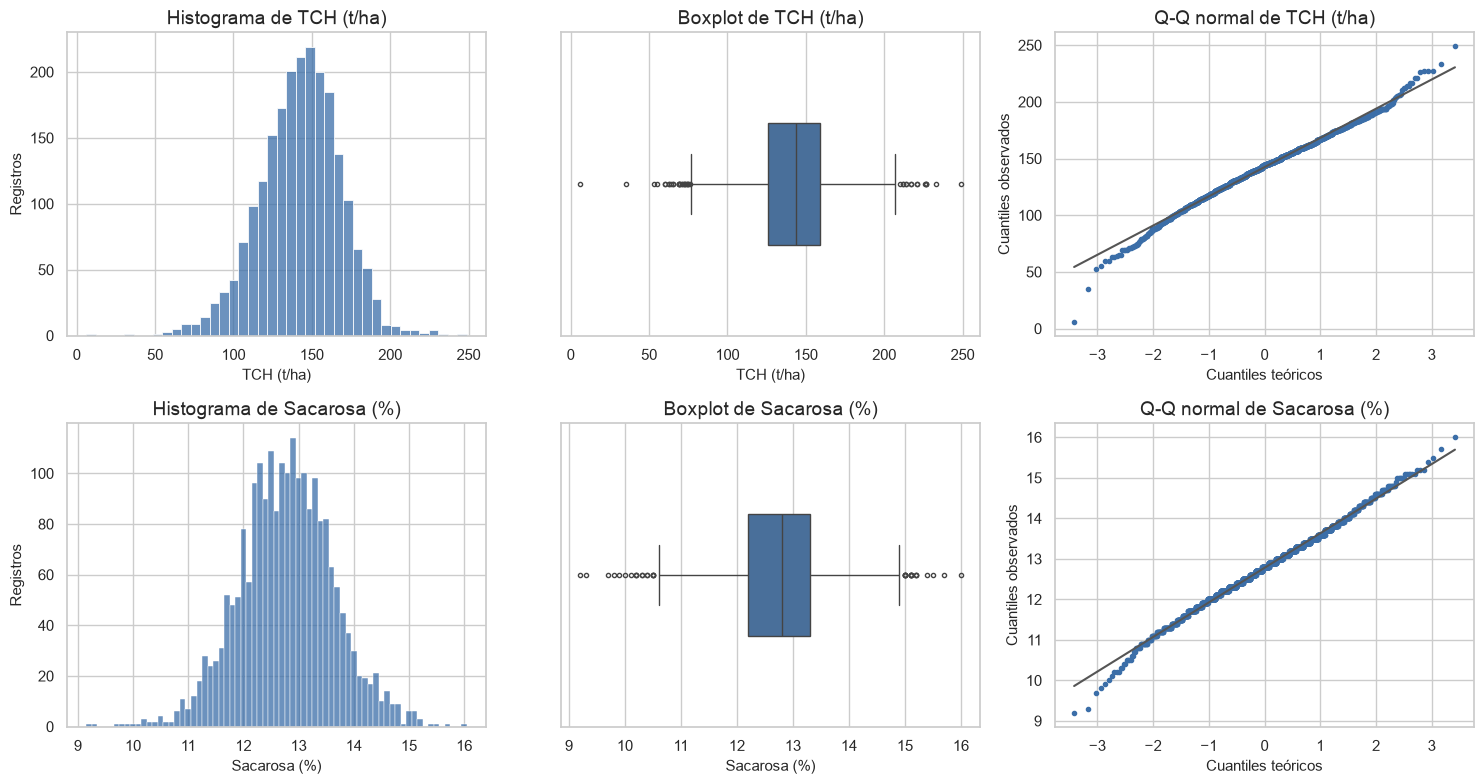

,media,mediana,desv_estandar,asimetria,curtosis_exceso,p_valor_normalidad
TCH,142.3932,144.0,25.8380,-0.2250,0.8609,0.0000
sacarosa,12.7777,12.8,0.8544,-0.0437,0.5085,0.0002


In [66]:
# 4.1 Distribución y normalidad de los targets
targets = {"TCH": "TCH (t/ha)", "sacarosa": "Sacarosa (%)"}
color = "#3B6EA8"

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for fila, (col, etiqueta) in zip(axes, targets.items()):
    x = df_ipsa[col]

    # Sacarosa se registra con un decimal: un bin por valor posible evita barras alternadas artificiales
    bins = 40 if col == "TCH" else np.arange(x.min() - 0.05, x.max() + 0.1, 0.1)
    sns.histplot(x, bins=bins, color=color, edgecolor="white", ax=fila[0])
    fila[0].set(title=f"Histograma de {etiqueta}", xlabel=etiqueta, ylabel="Registros")

    sns.boxplot(x=x, color=color, width=0.4, fliersize=3, ax=fila[1])
    fila[1].set(title=f"Boxplot de {etiqueta}", xlabel=etiqueta)

    stats.probplot(x, dist="norm", plot=fila[2])
    puntos, recta = fila[2].get_lines()
    puntos.set(color=color, markersize=3)
    recta.set(color="#555555", linewidth=1.5)
    fila[2].set(title=f"Q-Q normal de {etiqueta}", xlabel="Cuantiles teóricos",
                ylabel="Cuantiles observados")

plt.tight_layout()
plt.show()

# Estadísticos de forma y prueba de normalidad de D'Agostino-Pearson
forma = pd.DataFrame({
    col: {
        "media": df_ipsa[col].mean(),
        "mediana": df_ipsa[col].median(),
        "desv_estandar": df_ipsa[col].std(),
        "asimetria": stats.skew(df_ipsa[col]),
        "curtosis_exceso": stats.kurtosis(df_ipsa[col]),
        "p_valor_normalidad": stats.normaltest(df_ipsa[col]).pvalue,
    }
    for col in targets
}).T
display(forma.round(4))

#### Conclusión de 4.1

- **TCH** tiene una distribución unimodal con media (142.4 t/ha) y mediana (144 t/ha) muy cercanas y una
  asimetría leve hacia la izquierda (−0.23). La curtosis de exceso de 0.86 indica colas más pesadas que
  las de una distribución normal. El gráfico Q-Q muestra que el centro sigue la recta y que la
  desviación se concentra en los extremos: por debajo de unas 75 t/ha, con dos valores aislados cerca de
  6 y 35 t/ha, y por encima de unas 210 t/ha.
- **Sacarosa** tiene una distribución unimodal y prácticamente simétrica (asimetría de −0.04), con media
  de 12.78 % y mediana de 12.8 %. Su dispersión es baja (desviación estándar de 0.85 puntos). El
  gráfico Q-Q sigue la recta en casi todo el rango y solo se separa en la cola inferior, por debajo de
  unos 10.5 %.
- La prueba de D'Agostino-Pearson rechaza la normalidad en ambos casos (p < 0.001). Con 2.187 registros,
  la prueba es sensible a desviaciones pequeñas. Los gráficos muestran que la desviación se debe a colas
  más pesadas que las normales, no a una forma distinta en el centro de la distribución.
- La normalidad de los targets no es un requisito para los modelos de clasificación: las clases se
  construyen con umbrales sobre cada target, y ni la regresión logística ni KNN suponen una distribución
  para él. Lo relevante para las secciones siguientes son las colas, que se revisan en 4.2.
- La baja dispersión de la sacarosa implica que las fronteras entre clases van a quedar separadas por
  pocas décimas. Un error de 0.5 puntos en una predicción puede cambiar la clase asignada.

### 4.2 Valores extremos de los targets

Para TCH se usan los criterios del Ingenio. Valores entre 180 y 200 t/ha no son atípicos y corresponden
a suertes de alta productividad. Valores superiores a 250 t/ha son inusuales y requieren revisión.
Valores inferiores a 50-60 t/ha suelen corresponder a cosechas de semilla registradas como cosecha
comercial, así que se consideran errores de registro.

Para sacarosa no hay un criterio equivalente. Los registros fuera de los bigotes del boxplot
(1.5 × IQR) se revisan como candidatos, no se excluyen automáticamente. Para cada uno se contrastan
`vejez` y `me`: aunque se excluyeron como predictores, ambas explican pérdidas de sacarosa después
del corte. Una sacarosa baja acompañada de mucho tiempo hasta el molino o de mucha materia extraña
corresponde a un evento real y no a un error de registro.

In [67]:
# 4.2 Valores extremos de los targets
cols_ctx = ["FAZ", "TAL", "periodo", "edad", "cortes", "TCH", "sacarosa", "vejez", "me"]

# TCH según los criterios del Ingenio
print("TCH < 60:", (df_ipsa["TCH"] < 60).sum(),
      "| TCH > 200:", (df_ipsa["TCH"] > 200).sum(),
      "| TCH > 250:", (df_ipsa["TCH"] > 250).sum())
display(df_ipsa.loc[df_ipsa["TCH"] < 60, cols_ctx].sort_values("TCH"))
display(df_ipsa.loc[df_ipsa["TCH"] > 200, cols_ctx].sort_values("TCH"))

# Sacarosa: candidatos fuera de los bigotes del boxplot (solo para revisión)
q1, q3 = df_ipsa["sacarosa"].quantile([0.25, 0.75])
lim_inf, lim_sup = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
sac_baja = df_ipsa["sacarosa"] < lim_inf
sac_alta = df_ipsa["sacarosa"] > lim_sup
print(f"Límites de los bigotes: {lim_inf:.2f} - {lim_sup:.2f} | "
      f"por debajo: {sac_baja.sum()} | por encima: {sac_alta.sum()}")

# ¿Los registros con sacarosa extrema tienen más vejez o materia extraña que el resto?
grupo_sac = np.select([sac_baja, sac_alta], ["baja", "alta"], default="resto")
display(df_ipsa.groupby(grupo_sac)[["vejez", "me", "edad", "semsmad"]].median().round(2)
        .assign(n_registros=pd.Series(grupo_sac).value_counts()))
display(df_ipsa.loc[sac_baja, cols_ctx].sort_values("sacarosa"))

TCH < 60: 4 | TCH > 200: 23 | TCH > 250: 0


,FAZ,TAL,periodo,edad,cortes,TCH,sacarosa,vejez,me
664,81353,130,201805,15.2,3,6,11.2,6.5,12.7
1118,80527,033B,201905,11.2,2,35,12.9,3.5,9.8
959,80261,001D,202010,12.7,2,53,13.6,1.6,9.4
85,80187,3,201902,11.0,2,55,12.3,4.2,9.0


,FAZ,TAL,periodo,edad,cortes,TCH,sacarosa,vejez,me
767,80944,10,201903,12.3,4,202,12.0,2.8,10.8
300,81313,8,201905,12.0,2,202,11.4,2.6,12.0
1200,80604,8,201704,13.5,1,203,12.6,1.8,10.1
303,81313,9,201905,11.5,2,204,11.2,2.4,12.7
532,80127,002X,201710,14.2,3,205,12.8,2.8,11.9
584,80222,2,201708,15.2,1,206,12.3,5.5,6.3
919,80296,5,201603,13.1,1,206,12.0,2.1,7.6
1398,80172,4,201904,13.4,1,207,11.4,2.3,9.6
661,80173,002A,201703,13.8,1,210,12.0,2.6,11.0
172,80307,4,201706,14.6,1,212,11.0,2.7,8.0


Límites de los bigotes: 10.55 - 14.95 | por debajo: 18 | por encima: 19


,vejez,me,edad,semsmad,n_registros
alta,3.20,7.5,12.9,10.90,19
baja,3.15,10.3,13.2,8.05,18
resto,2.60,9.1,12.5,8.70,2150


,FAZ,TAL,periodo,edad,cortes,TCH,sacarosa,vejez,me
1182,80122,28,201912,12.8,5,122,9.2,51.3,15.0
1261,80328,5,201709,21.1,3,129,9.3,3.0,13.1
515,80228,2,201611,14.2,2,168,9.7,2.3,10.6
1734,80154,9,201708,15.2,3,144,9.8,20.4,6.0
156,81054,4,201704,12.1,2,125,9.9,2.7,12.9
1749,80528,006C,202008,12.4,2,121,10.0,4.7,10.0
1827,80150,004A,201905,12.3,1,161,10.1,3.3,11.5
1809,80206,1,201702,13.8,1,147,10.2,2.3,10.7
1793,80281,001D,201705,13.0,1,124,10.2,2.6,8.7
721,81363,10,201801,13.4,3,147,10.2,2.5,7.8


#### Conclusión de 4.2

**TCH**

- Cuatro registros tienen TCH por debajo de 60 t/ha: 6, 35, 53 y 55. El Ingenio asocia estos valores a
  cosechas de semilla registradas como cosecha comercial. Sin embargo, sus edades (11.0 a 15.2 meses)
  están dentro del rango habitual, así que la edad no permite confirmar esa explicación.
- Un TCH tan bajo no representa la productividad de una suerte completa, aunque su causa no se puede
  establecer con los datos disponibles. Los cuatro registros se consideran errores de registro de TCH
  y se marcan con la variable `excluir_tch`. **Se excluyen solo de la clasificación de TCH** y se
  conservan para la de sacarosa, porque la sacarosa se mide en laboratorio sobre la caña entregada y
  no depende del área registrada. Es el mismo criterio (TCH < 60 t/ha, solo en el modelo de TCH) que se
  aplica en el análisis del histórico de suertes.
- 23 registros superan las 200 t/ha, con un máximo de 249. Ninguno supera el umbral de 250 t/ha que el
  Ingenio considera inusual, y varios corresponden a los mismos sitios en años distintos (la suerte 10
  de la hacienda 80944 en 2017, 2018 y 2019). Corresponden a suertes de alta productividad y **se
  conservan**.

**Sacarosa**

- 18 registros están por debajo del bigote inferior (10.55 %) y 19 por encima del superior (14.95 %).
- Los registros con sacarosa baja tienen más materia extraña (mediana de 10.3 frente a 9.1 en el resto)
  y más horas entre el corte y el molino (3.15 frente a 2.60). Cuatro de ellos superan las 20 horas
  (hasta 51.3 h), algo excepcional en el dataset. Ambos factores explican pérdidas reales de sacarosa.
- Los registros con sacarosa alta tienen más semanas de maduración (10.9 frente a 8.7) y menos materia
  extraña (7.5), lo que es coherente con un mayor efecto del madurante y una caña entregada más limpia.
- No hay evidencia de errores de registro en ninguno de los dos extremos. **Todos se conservan.**

Parte de la variación de la sacarosa se explica por factores posteriores al corte (`vejez` y `me`),
que no están disponibles antes de la cosecha. Esto limita la capacidad de cualquier modelo para
anticipar la clase de sacarosa, y se espera un desempeño menor que en TCH.

In [68]:
# TCH < 60 t/ha: errores de registro según 4.2
# Se marcan en vez de eliminarse, porque su sacarosa es válida y se usa en la clasificación de sacarosa
df_ipsa["excluir_tch"] = df_ipsa["TCH"] < 60
print("Registros marcados con excluir_tch:", df_ipsa["excluir_tch"].sum(), "| Registros totales:", len(df_ipsa))

Registros marcados con excluir_tch: 4 | Registros totales: 2187
